In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import gzip
from sklearn.preprocessing import StandardScaler

# Loading the Data

In [35]:
classLabels = pd.read_csv("./data/class.tsv", sep='\t', header=None)
classLabels.columns = ['Class']

with gzip.open("./data/filtered.tsv.gz", 'rt') as f:
    expressionData = pd.read_csv(f, sep='\t', header=0)

expressionData.columns = expressionData.columns.str.strip()
expressionData.columns = expressionData.columns.astype(str)

with gzip.open("./data/columns.tsv.gz", 'rt') as f:
    geneNames = pd.read_csv(f, sep='\t', skiprows=18)

# Processing Expression Data

In [36]:
geneNames = geneNames[['ID', 'GeneSymbol']].dropna()

genes = geneNames[geneNames['GeneSymbol'].isin(['XBP1', 'GATA3'])]
geneIDMap = dict(zip(genes['GeneSymbol'], genes['ID'].astype(str)))

plotData = expressionData[[geneIDMap['GATA3'], geneIDMap['XBP1']]].copy()
plotData.columns = ['GATA3', 'XBP1']
plotData['Class'] = classLabels['Class'].values

# Scatter Plot

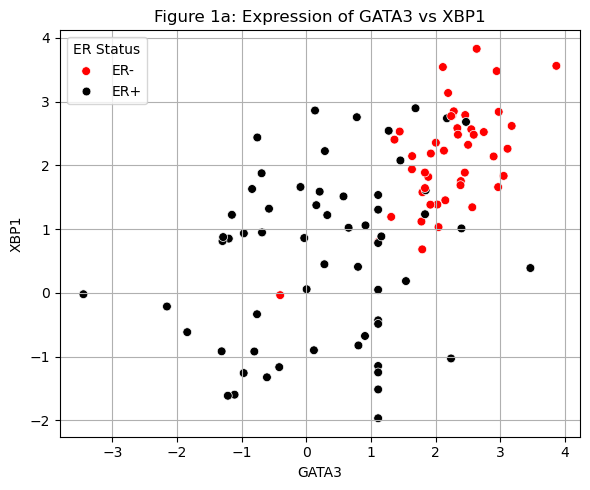

In [47]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=plotData, x='GATA3', y='XBP1', hue='Class', palette={1: 'red', 0: 'black'}, s=40)
plt.title("Figure 1a: Expression of GATA3 vs XBP1")
plt.legend(title="ER Status", labels=["ER-", "ER+"])
plt.grid(True)
plt.tight_layout()
plt.show()

# Performing PCA

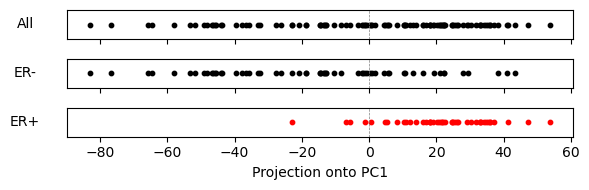

In [62]:
X = expressionData.values
pca = PCA(n_components=2)
PCAX = pca.fit_transform(X)

proj_df = pd.DataFrame({
    'PC1': PCAX[:, 0],
    'Class': classLabels['Class'].values
})


fig, axes = plt.subplots(3, 1, figsize=(6, 2), sharex=True)

labels = ['All', 'ER-', 'ER+']
colors = ['black', 'black', 'red']

for i in range(3):
    if labels[i] == 'All':
        data = proj_df
    elif labels[i] == 'ER-':
        data = proj_df[proj_df['Class'] == 0]
    else:
        data = proj_df[proj_df['Class'] == 1]

    axes[i].scatter(data['PC1'], [0]*len(data), color=colors[i], s=10)
    axes[i].set_yticks([])
    axes[i].set_ylabel(labels[i], rotation=0, labelpad=30, va='center')
    axes[i].axvline(0, linestyle='--', color='gray', lw=0.5)

axes[-1].set_xlabel("Projection onto PC1")
plt.tight_layout()
plt.show()